# Bank Customer Marketing Analysis

In [59]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#2196F3', '#F44336']
sns.set_palette(PALETTE)

In [21]:
# Importing Data

DATA_PATH = r"C:\Users\Abhishek\Desktop\MLOps\Customer Churn Prediction\src\data\raw_data\data.csv"

df = pd.read_csv(
    DATA_PATH
    )

# Dropping unwanted columns
df = df.drop(columns=["customerID"])

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()


Shape: (7043, 20)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Data Information

In [22]:
df.info() # Data have no null values on high level view

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Checking for duplicates values

In [24]:
df.duplicated().sum() # there is no duplicate values in our data

np.int64(22)

## Checking for datatype issues

In [25]:
df.dtypes # no datatype issues

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Handling Null Values

In [26]:
df.isna().sum() # No null value in the dataset

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Category count inspection of each columns

In [27]:
for col in df.select_dtypes(include=['object']).columns.to_list():
    print("Column Name:")
    print(df[col].value_counts())
    print("=="*30)

Column Name:
gender
Male      3555
Female    3488
Name: count, dtype: int64
Column Name:
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Column Name:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
Column Name:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
Column Name:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
Column Name:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
Column Name:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
Column Name:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
Column Name:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64
Column Name:
TechSupport
No                   

## EDA

In [28]:
# --- Fix dtypes ---
# SeniorCitizen: convert 0/1 → 'No'/'Yes' to be consistent with other categorical columns
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# TotalCharges: contains blank spaces → convert to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count missing values after conversion
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Fill NaN in TotalCharges with 0 (new customers with tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Check duplicates
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Final shape: {df.shape}")

Missing values in TotalCharges: 11
Duplicates: 22
Final shape: (7043, 20)


Churn
No     5174
Yes    1869
Name: count, dtype: int64


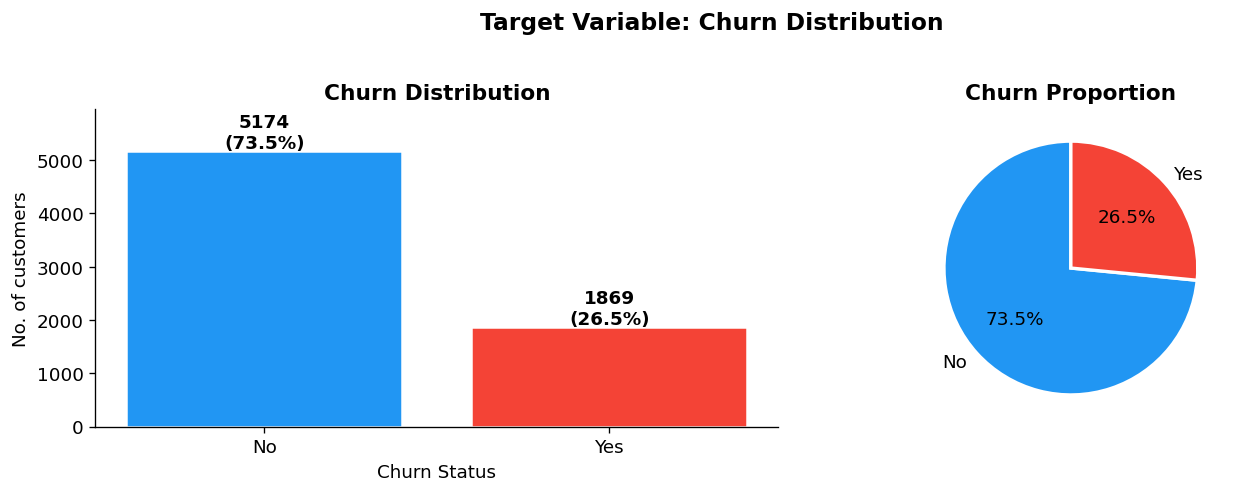

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
print(churn_counts)

axes[0].bar(churn_counts.index, churn_counts.values, color=PALETTE, edgecolor='white', linewidth=1.5)
for i, (label, v) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, v + 50, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('No. of customers')
axes[0].set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Target Column Distribution

## Integer Column Distribution

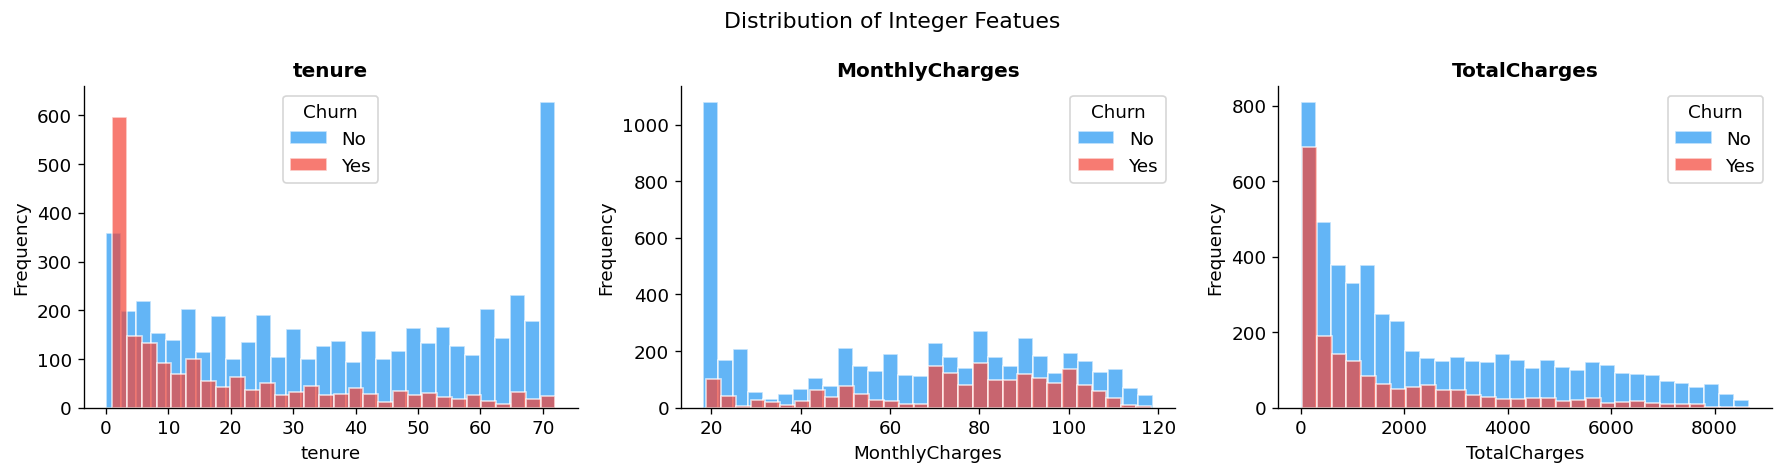

In [60]:
int_cols = df.select_dtypes(include=["int", 'float']).columns.to_list()

fig, axes = plt.subplots(1, len(int_cols), figsize=(15,4))

for ax, col in zip(axes, int_cols):
    for label, color in zip(["No", "Yes"], PALETTE):
        data = df[df["Churn"] == label][col]
        ax.hist(data, bins=30, alpha=0.7, label = label, color = color, edgecolor="white")
    ax.set_title(f"{col}", fontsize=12, fontweight= "bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(title = "Churn")

plt.suptitle("Distribution of Integer Featues")
plt.tight_layout()
plt.show()


## Categorical Column Vs Churn Rate

In [75]:
df.groupby('gender').apply(lambda x: (x['Churn'] == "Yes").sum())

gender
Female    939
Male      930
dtype: int64

In [76]:
# Churn rate
df.groupby('gender')['Churn'].apply(lambda x: (x == "Yes").mean() * 100).reset_index()

,gender,Churn
0,Female,26.920872
1,Male,26.160338


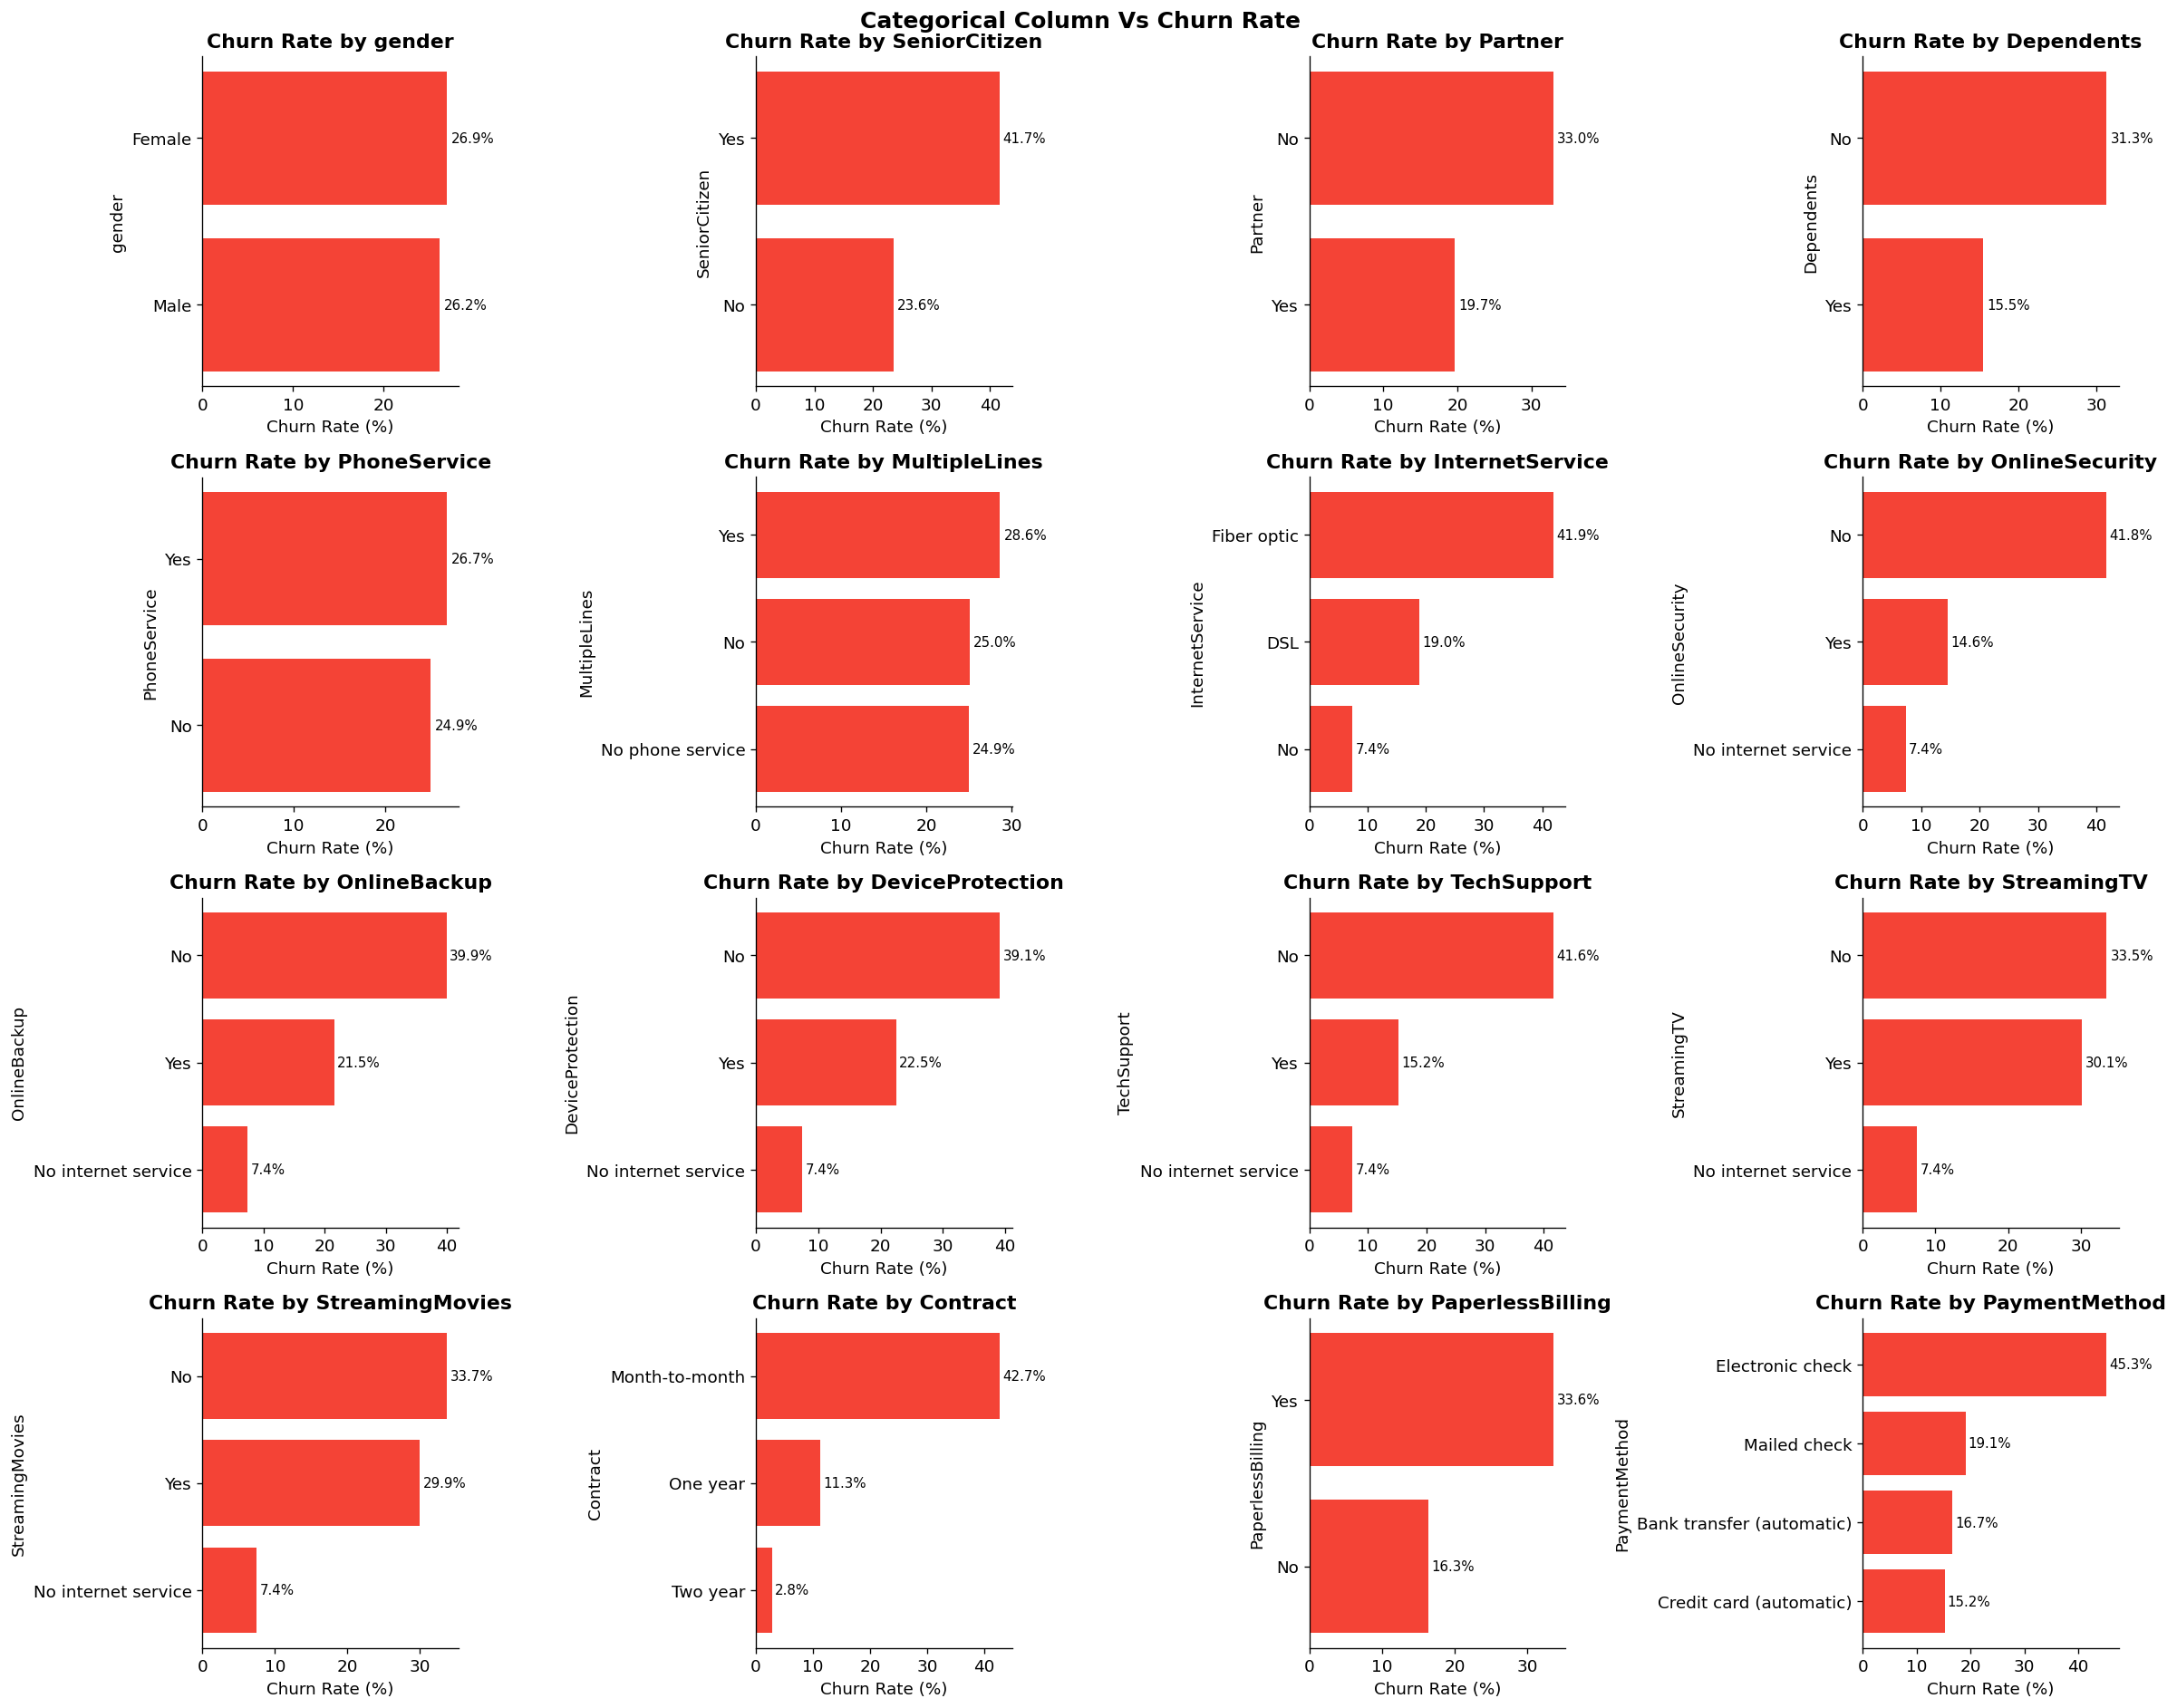

In [100]:
cat_cols = df.select_dtypes(include=["object"]).columns.to_list()

# Remove 'Churn' from categorical columns
cat_cols = [col for col in cat_cols if col != "Churn"]

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

# Flatten axes into a 1D array so we can zip with cat_cols
axes = axes.ravel()

for ax, col in zip(axes, cat_cols):
    if col == "Churn":
        continue

    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).reset_index(name="ChurnRate")
    churn_rate.columns = [col, "ChurnRate"]
    churn_rate = churn_rate.sort_values('ChurnRate', ascending=True)

    bar = ax.barh(churn_rate[col], churn_rate["ChurnRate"], color="#F44336")
    for bar, value in zip(bar, churn_rate["ChurnRate"]):
        ax.text(value + 0.5, bar.get_y() + bar.get_height()/2, f'{value:.1f}%', va='center', fontsize=9)
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel(col)
    ax.set_title(f"Churn Rate by {col}", fontweight='bold')

plt.suptitle('Categorical Column Vs Churn Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## Checking for Outliers

In [112]:
def outlier_detect(df: pd.DataFrame):
    for col in df.select_dtypes(include=['int', "float"]).columns.to_list():
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        IQR = q3 - q1

        min = q1 - 1.5 * IQR
        max = q3 + 1.5 * IQR

        filter = (df[col] < min) | (df[col] > max)
        outlier = df[filter]
        print(f"Column Name: {col}")
        display(outlier[col])
    return None
    

In [113]:
outlier_detect(df = df)

Column Name: tenure


Series([], Name: tenure, dtype: int64)

Column Name: MonthlyCharges


Series([], Name: MonthlyCharges, dtype: float64)

Column Name: TotalCharges


Series([], Name: TotalCharges, dtype: float64)

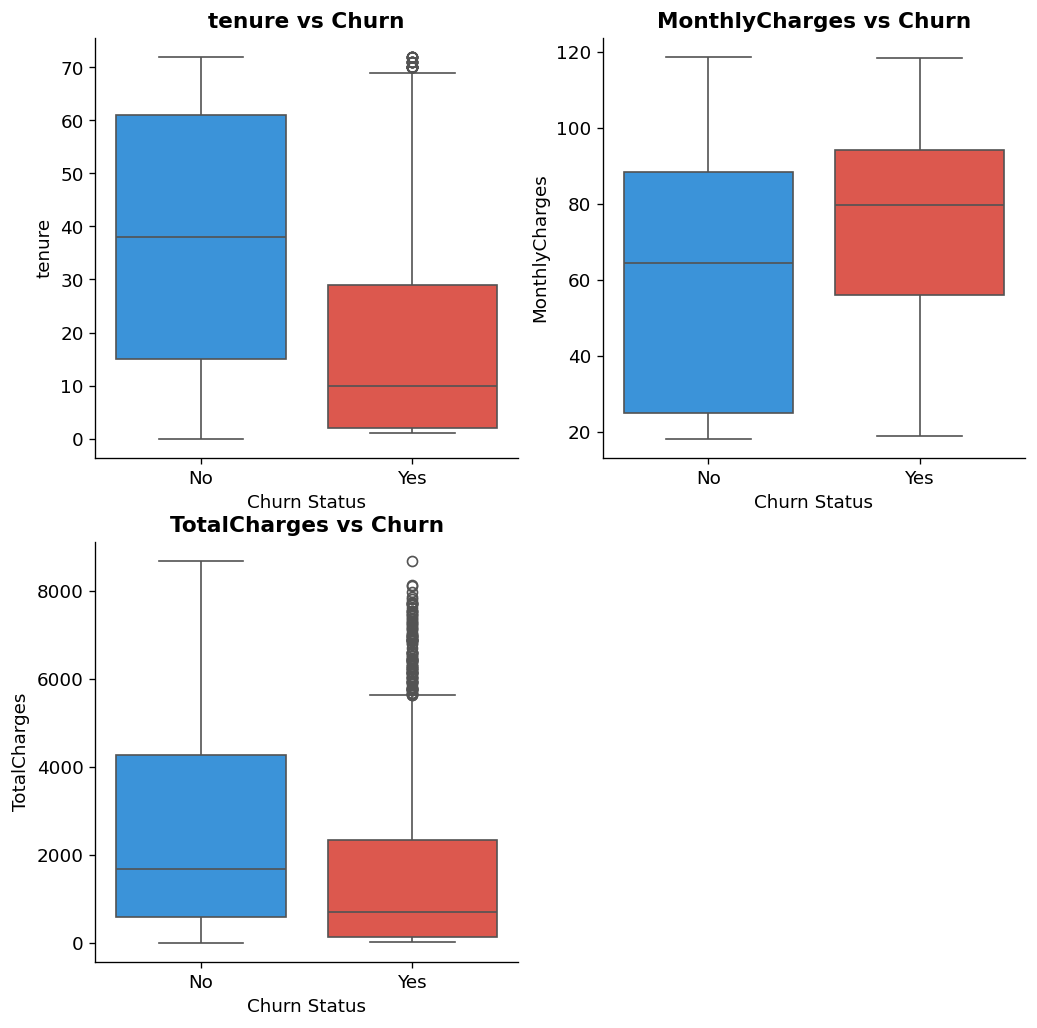

In [140]:
col_name = df.select_dtypes(include=['int', 'float']).columns.to_list()

n_col = 2
n_rows = (len(col_name) + n_col -1 ) // n_col

fig, axes = plt.subplots(n_rows, n_col, figsize=(10,10))
axes = axes.flatten()
for ax,col in zip(axes, col_name):
    sns.boxplot(data = df, x = "Churn", y = col, ax=ax, palette=PALETTE)
    ax.set_title(f'{col} vs Churn', fontsize=13, fontweight='bold')
    ax.set_xlabel('Churn Status')
    ax.set_ylabel(col)

    for ax in axes[len(col_name):]:
        ax.set_visible(False)

plt.show()

## Feature Engineering

In [165]:
feature_df = df.copy()

services = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Adding total services
feature_df['TotalServices'] = (feature_df[services] == 'Yes').sum(axis=1)

# Charges Per Service Charge
feature_df['ChargePerService'] = feature_df["MonthlyCharges"] / feature_df["TotalServices"]

# New customer or not
feature_df['IsNewCustomer'] = (df['tenure'] <= 3).map({True: "Yes", False: "No"})

# long term contract
feature_df['IsLongTerm'] = (feature_df['Contract'] != 'Month-to-month').map({True: 'Yes', False: 'No'})

# Tenure Grouping
feature_df['TenureGroup'] = pd.cut(
    feature_df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'],
    right=True
)
feature_df['TenureGroup'] = feature_df['TenureGroup'].astype(str)

# samples
new_features = ['TotalServices', 'ChargePerService', 'IsNewCustomer', 'IsLongTerm', 'TenureGroup']

for f in new_features:
    print(f'   - {f}: {feature_df[f].dtype} | sample: {feature_df[f].head(3).tolist()}')
print(f'\nCek TenureGroup NaN: {feature_df["TenureGroup"].isna().sum()} (harus 0)')

   - TotalServices: int64 | sample: [1, 3, 3]
   - ChargePerService: float64 | sample: [29.85, 18.983333333333334, 17.95]
   - IsNewCustomer: object | sample: ['Yes', 'No', 'Yes']
   - IsLongTerm: object | sample: ['No', 'Yes', 'No']
   - TenureGroup: object | sample: ['0-1yr', '2-4yr', '0-1yr']

Cek TenureGroup NaN: 0 (harus 0)


In [186]:
services = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]

for c in services:
    print(feature_df[c].unique())

['No' 'Yes']
['No phone service' 'No' 'Yes']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


In [188]:
feature_df["TotalServices"].unique()

array([1, 3, 5, 4, 6, 2, 8, 7, 0])

In [179]:
c = feature_df.select_dtypes(include=['object']).columns.to_list()

for col in c:
    print(col)
    print(feature_df[col].unique())
    print("-"*50)


gender
['Female' 'Male']
--------------------------------------------------
SeniorCitizen
['No' 'Yes']
--------------------------------------------------
Partner
['Yes' 'No']
--------------------------------------------------
Dependents
['No' 'Yes']
--------------------------------------------------
PhoneService
['No' 'Yes']
--------------------------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity
['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup
['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection
['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport
['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV
['No' 'Yes' 'No in

In [182]:
list(feature_df["IsNewCustomer"].unique())

['Yes', 'No']

## Skewness in Data

Skewness:
 tenure              0.239540
MonthlyCharges     -0.220524
TotalCharges        0.963235
TotalServices       0.450807
ChargePerService         NaN
dtype: float64


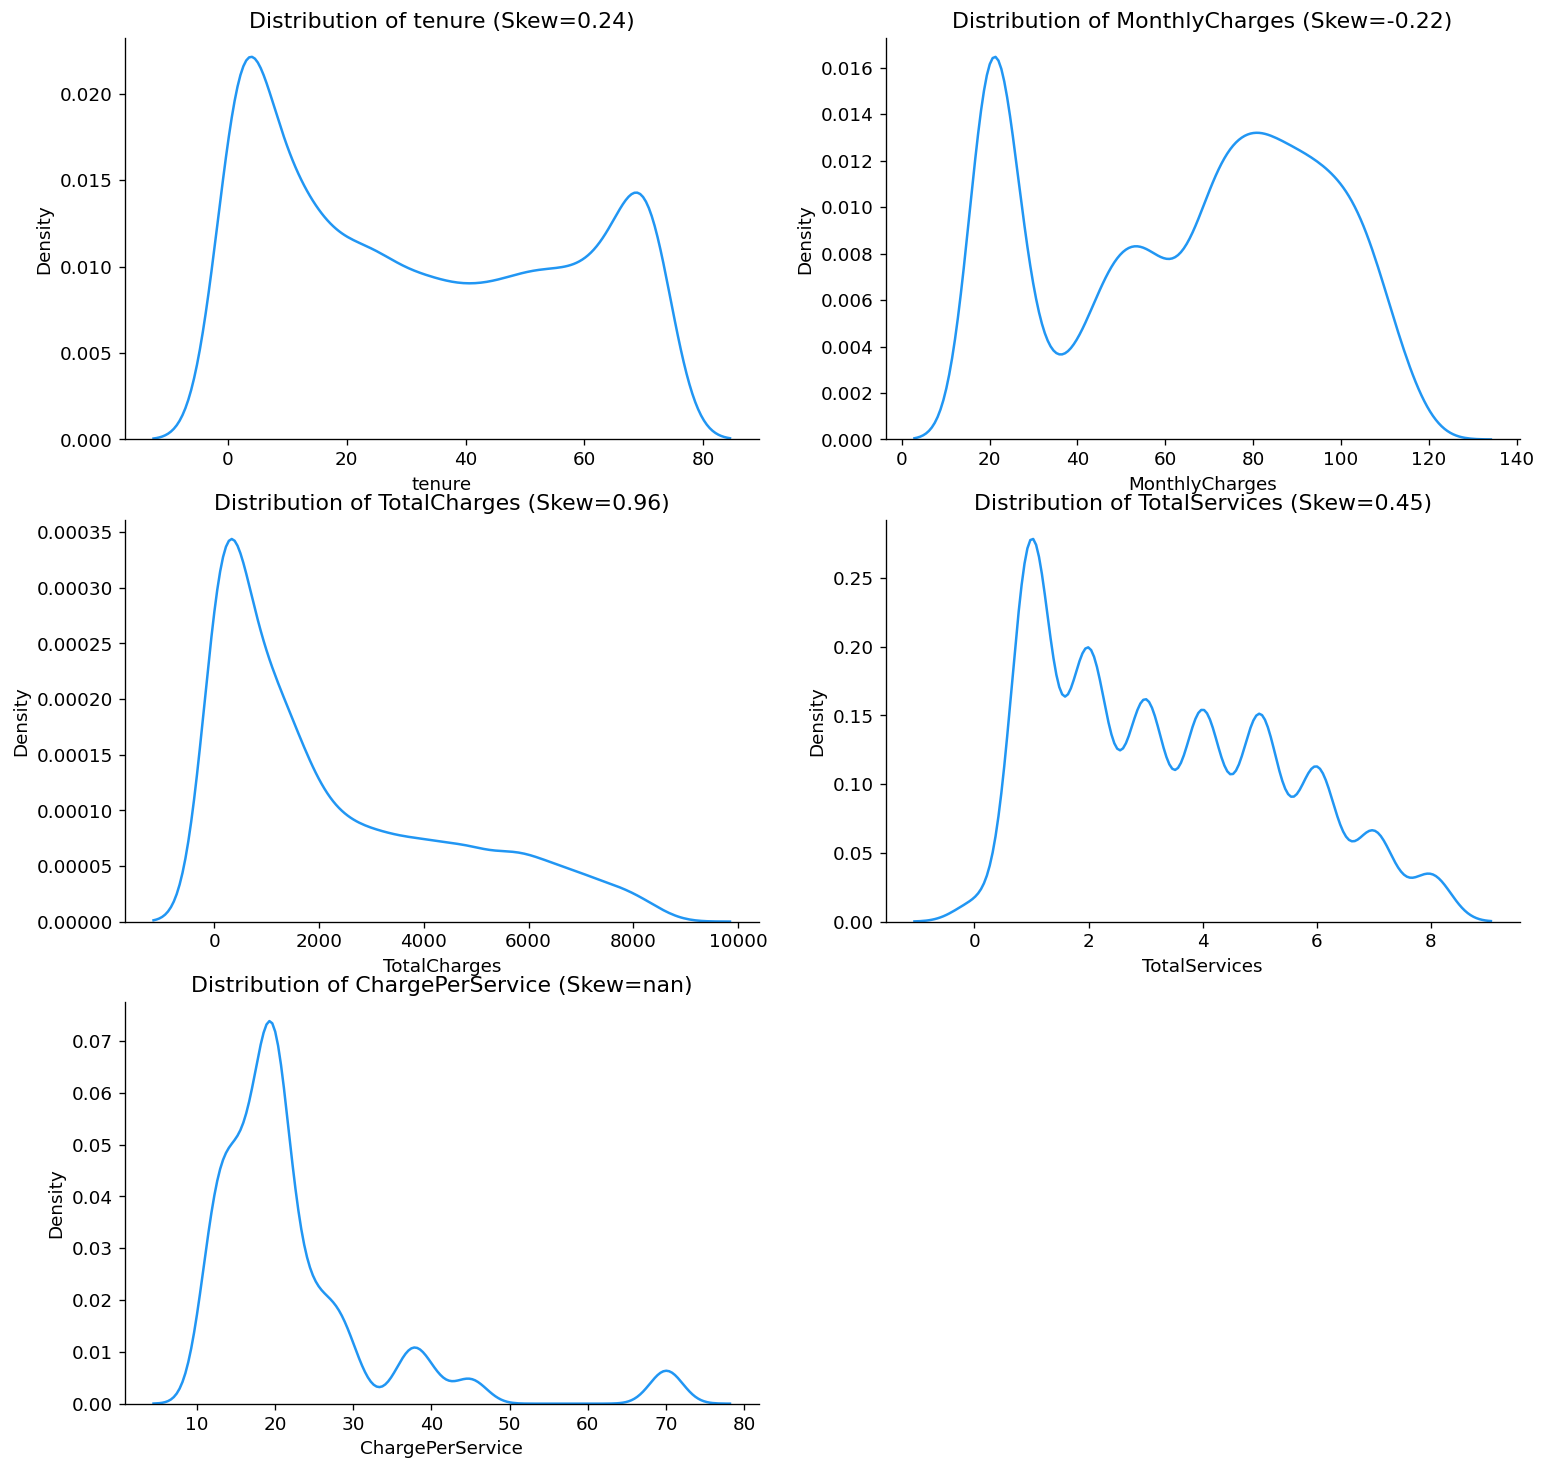

In [169]:
numeric_cols = feature_df.select_dtypes(include=['int','float']).columns

# Calculate skewness
skew_values = feature_df[numeric_cols].skew()

print("Skewness:\n", skew_values)

plt.figure(figsize=(15,20))
for idx,col in enumerate(numeric_cols):
    plt.subplot(4,2,idx+1)
    sns.kdeplot(feature_df[col])
    plt.title(f"Distribution of {col} (Skew={skew_values[col]:.2f})")
plt.show()

Looking at your skewness plots:

- Moderate skew:
    
    age (0.68) → mild right skew, usually fine.
    
    day (0.09) → nearly symmetric, no action needed.

- High skew:
   
    balance (8.36), duration (3.14), campaign (4.90), pdays (2.62) → strongly right-skewed.
    
    previous (41.85) → extremely skewed, almost all values near zero with a very long tail.


- **Out Approach** 

    We are not planning of using any linear assumption models or distance base model, 
    
    the tree base models are robust to skewness hence we will not be removing skewness.

## Checking for feature Correlation

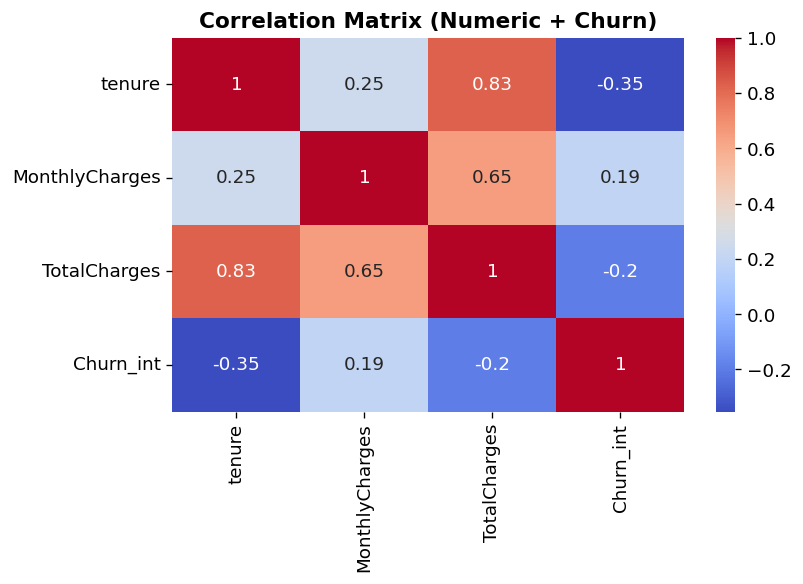

In [170]:
fig, axes = plt.subplots(figsize=(7,5))

corr = df[int_cols + ["Churn"]].copy()
corr['Churn_int'] = (corr["Churn"] == "Yes").astype(int)
corr= corr.drop(columns= ['Churn'])

corr_df = corr.corr()
sns.heatmap(corr_df, annot=True, cmap="coolwarm")

axes.set_title('Correlation Matrix (Numeric + Churn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Diagonal values = 1  
Each variable is perfectly correlated with itself.

Tenure vs TotalCharges → 0.83 (strong positive)  
Customers with longer tenure tend to have higher total charges. Makes sense: the longer they stay, the more they pay overall.

MonthlyCharges vs TotalCharges → 0.65 (moderate positive)  
Higher monthly charges contribute to higher total charges, but tenure also plays a role, so correlation isn’t perfect.

Tenure vs MonthlyCharges → 0.25 (weak positive)  
Tenure and monthly charges aren’t strongly related — a long‑tenured customer might have low or high monthly charges depending on their plan.

Tenure vs Churn_int → -0.35 (moderate negative)  
Longer‑tenured customers are less likely to churn. This is a common finding in churn datasets: loyalty builds over time.

MonthlyCharges vs Churn_int → 0.19 (weak positive)  
Customers with higher monthly charges are slightly more likely to churn, but the relationship isn’t very strong.

TotalCharges vs Churn_int → -0.20 (weak negative)  
Customers with higher total charges (i.e., long‑term customers) are less likely to churn.

In [171]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
